![](../figure/dumbbell_2d.svg)

In [2]:
%matplotlib widget
%reset -f
%load_ext autoreload
%autoreload 1
%aimport mechanics

from sympy import *
from mechanics import *
import mechanics.space as space

t, = base_spaces('t')
def dot(f): return diff(f, t)

# Generalized coordinates
r, = variables('r', t)
theta, psi = variables(r'\theta, \psi', t, space=space.S)

q = r, theta, psi
dq = tuple(dot(q_n) for q_n in q)
ddq = tuple(dot(dq_n) for dq_n in dq)

# Parameters
# mu: gravitational constant of central body
# m: mass of dumbbell satellite
# I: moment of inertia of dumbbell satellite about mass center
# l: length of dumbbell satellite
mu, m, I, l = constants(r'\mu m I \ell')

# Lagrangian
U = - mu*m / r - mu/2 / r**3 * (2*I - 3*I*sin(psi)**2)
T = m/2 * dot(r)**2 + m/2 * (r*dot(theta))**2 + I/2 * (dot(theta + psi))**2
E = T + U
L = T - U
show('L =' , L)

def metric(v1, v2):
    return sum(diff(L, dq1_n, dq2_n) * v1_n * v2_n 
                for dq1_n, v1_n in zip(dq, v1) for dq2_n, v2_n in zip(dq, v2))

show(r'\|v\|^2 =', metric(dq, dq))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
I_lock = I + m*r**2
show(r'\mathbb{I} =', I_lock)

J_L = diff(L, dot(theta)).simplify()
show(r'J_\mathrm{L} =', J_L)

A = (J_L / I_lock)
show(r'\mathcal{A} =', A)

y = (r, psi)
dy = (dot(r), dot(psi))

A_ = tuple(diff(A, dot(y_gamma)) for y_gamma in y)
show(r'A =', A_)

ver = (0, A, 0)
hor = tuple((dq_n - ver_n).simplify() for dq_n, ver_n in zip(dq, ver))
show(r'\mathrm{ver}_q v =', ver)
show(r'\mathrm{hor}_q v =', hor)

nu, = variables(r'\nu', t)

U_nu = U + nu ** 2 / I_lock / 2
show(r'U_\nu =', U_nu)

R_nu = L - A * nu
show(r'R_\nu =', R_nu)
R_nu = metric(hor, hor) / 2 - U_nu
show(r'R_\nu =', R_nu)

B = tuple(tuple(diff(A_[a], y[gamma]) - diff(A_[gamma], y[a])
                for a in (0,1)) for gamma in (0,1))
show(r'B_{\gamma a} =', B)

LD = tuple(diff(diff(R_nu, dot(y[gamma])), t) - diff(R_nu, y[gamma]) - nu * sum(B[gamma][a] * dot(y[a]) for a in (0,1)) for gamma in (0,1))
show_equations(LD)

sol = solve(LD, ddq[0], ddq[2])
F = sp.Matrix((dq[0], dq[2]) + tuple(sol[ddq_n].simplify() for ddq_n in (ddq[0], ddq[2])))
show('F =', F)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

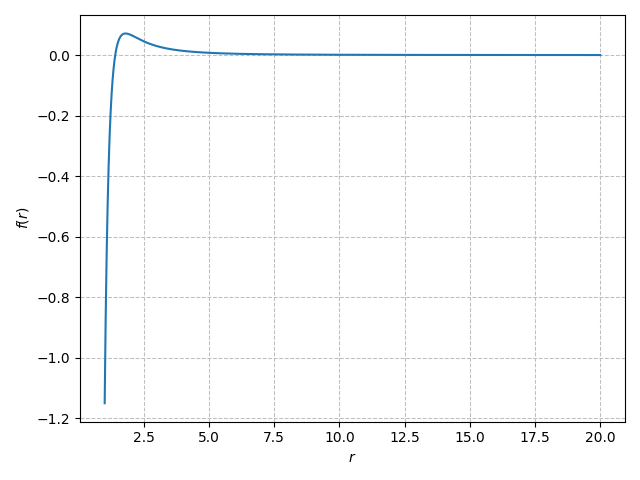

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

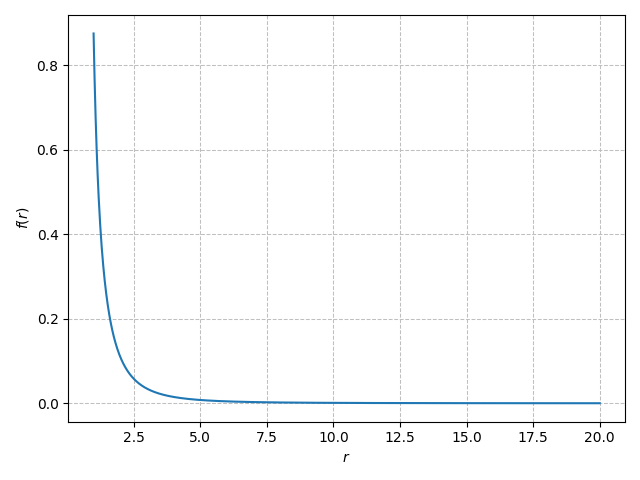

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
import spb

equib = {dq_n: 0 for dq_n in dq}
LD_eq = tuple(LD_n.subs(equib).simplify() for LD_n in LD)
show_equations(LD_eq)

derivatives = (
    (r'\frac{\partial^2 U_\nu}{\partial r^2}', diff(U_nu, r, 2)),
    (r'\frac{\partial^2 U_\nu}{\partial \psi^2}', diff(U_nu, psi, 2)),
    (r'\frac{\partial^2 U_\nu}{\partial r \partial \psi}', diff(U_nu, r, psi)),
)

equib1 = {psi: 0}
LD_eq1 = tuple(LD_n.subs(equib1).simplify() for LD_n in LD_eq)
show_equations(LD_eq1)
nu2 = simplify(solve(LD_eq1[0], nu**2)[0])
show(r'\nu^2 =', nu2)

for label, derivative in derivatives:
    show(label + ' =', derivative.subs(equib1).subs(nu**2, nu2).simplify())

spb.plot(derivatives[0][1].subs(equib1).subs(nu**2, nu2).subs({I: 1/4, m: 1, mu: 1}), (r, 1, 20))

equib2 = {psi: pi/2}
LD_eq2 = tuple(LD_n.subs(equib2).simplify() for LD_n in LD_eq)
show_equations(LD_eq2)
nu2 = simplify(solve(LD_eq2[0], nu**2)[0])
show(r'\nu^2 =', nu2)

for label, derivative in derivatives:
    show(label + ' =', derivative.subs(equib2).subs(nu**2, nu2).simplify())

spb.plot(derivatives[0][1].subs(equib2).subs(nu**2, nu2).subs({I: 1/4, m: 1, mu: 1}), (r, 1, 20))

Jac = sp.simplify(F.jacobian(y + dy).subs(equib).subs(equib2).subs(nu**2, nu2))
show('J =', Jac)
lambda_, = variables(r'\lambda')
eigen_eq = (Jac - sp.eye(4) * lambda_).det("berkowitz").subs(nu**2, nu2).simplify()
show(eigen_eq)

sol = sp.solve(eigen_eq, lambda_)
for s in sol:
    show(r'\lambda =', s.simplify())